# Green Route Travel Recommendation System
## Machine Learning Pipeline

This notebook demonstrates the complete ML workflow:
- Dataset loading
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Feature Scaling (if required)
- Model Training
- Model Evaluation
- Model Saving


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib


## Load Dataset

In [2]:
df = pd.read_csv('data/routes_dataset.csv')
df.head()

,from,to,distance_km,vehicle_type,fuel_type,traffic_level,road_type,co2_emission
0,Kochi,Indore,2000,bike,diesel,medium,highway,278.96
1,Indore,Nagpur,1084,bike,electric,high,highway,22.00
2,Bhopal,Bangalore,1443,bus,electric,low,rural,57.07
3,Indore,Patna,1568,bus,petrol,high,highway,294.95
4,Visakhapatnam,Pune,2094,bike,petrol,low,city,234.59


## Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   from           1500 non-null   object 
 1   to             1500 non-null   object 
 2   distance_km    1500 non-null   int64  
 3   vehicle_type   1500 non-null   object 
 4   fuel_type      1500 non-null   object 
 5   traffic_level  1500 non-null   object 
 6   road_type      1500 non-null   object 
 7   co2_emission   1500 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 93.9+ KB


## Check Missing Values

In [4]:
df.isnull().sum()

from             0
to               0
distance_km      0
vehicle_type     0
fuel_type        0
traffic_level    0
road_type        0
co2_emission     0
dtype: int64

## Statistical Summary

In [5]:
df.describe()

,distance_km,co2_emission
count,1500.000000,1500.000000
mean,1143.237333,122.905600
std,608.730440,108.546276
min,80.000000,1.590000
25%,628.000000,36.405000
50%,1119.000000,81.610000
75%,1654.500000,195.100000
max,2200.000000,508.900000


## Exploratory Data Analysis (EDA)

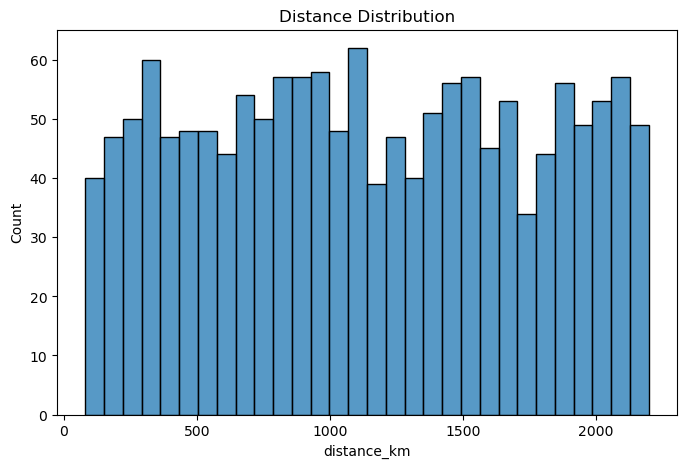

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['distance_km'], bins=30)
plt.title('Distance Distribution')
plt.show()

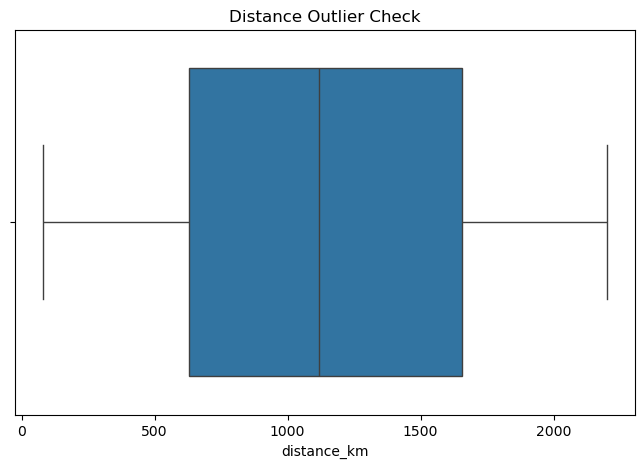

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['distance_km'])
plt.title('Distance Outlier Check')
plt.show()

## Feature Selection

In [8]:
X = df.drop('co2_emission', axis=1)
y = df['co2_emission']

## Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Preprocessing and Feature Scaling

In [10]:
categorical_features = [
    'from','to','vehicle_type','fuel_type','traffic_level','road_type'
]

numeric_features = ['distance_km']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

## Model Training (Random Forest)

In [11]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['from', 'to', 'vehicle_type',
                                                   'fuel_type', 'traffic_level',
                                                   'road_type']),
                                                 ('num', StandardScaler(),
                                                  ['distance_km'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

## Model Prediction

In [12]:
predictions = model.predict(X_test)

## Model Evaluation

In [15]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 42.19494657868839
MAE: 27.921847666666665
R2 Score: 0.8441176351935925


## Save Trained Model

In [ ]:
joblib.dump(model, 'models/emission_model.pkl')

## Conclusion
The Random Forest Regressor was used to predict CO2 emissions based on travel conditions.
This model can capture nonlinear relationships between features such as distance, traffic level,
vehicle type, and fuel type.